# Проблема множественных сравнений


Эта проблема несет командам экспериментов заметные угрозы и может называться по-разному: проблема множественных сравнений, множественного тестирования или множественной проверки гипотез. На английском тоже можно встретить несколько вариантов: multiple comparisons, multiplicity и multiple testing problem.

Проблема множественного тестирования — распространенная проблема в статистике, которая возникает при одновременном проведении нескольких проверок гипотез на одном наборе данных. При этом неправильно интерпретируются результаты: без учета повышенной вероятности получения ложноположительных результатов (ошибка I рода) заметно растет кумулятивная ошибка первого рода (**FWER**, Family-Wise Error Rate).

## Примеры множественных сравнений

Когда нужно учитывать множественные сравнения:

- Несколько независимых A/B-тестов
- Сравнение групп после ANOVA (post-hoc)
- Много признаков в регрессии
- Фильтрация признаков по p-value

1. A/B/n-тестирование с несколькими вариантами, например тестируем несколько вариантов кнопки (A, B, C, D)
- H0: Конверсия варианта B = варианта A
- H0: Конверсия варианта C = варианта A
- H0: Конверсия варианта D = варианта A

2. Анализ по сегментам, например проверяем, отличается ли ARPU по 5 сегментам пользователей
- H0: ARPU сегмента 1 = ARPU сегмента 2
- H0: ARPU сегмента 1 = ARPU сегмента 3
- H0: ARPU сегмента 1 = ARPU сегмента 4
- H0: ARPU сегмента 1 = ARPU сегмента 5
- ... и так далее (всего 10 сравнений для 5 групп)


3. Проверка эффективности множества фичей в ML
- H0: Коэффициент при feature_1 = 0
- H0: Коэффициент при feature_2 = 0
- ...

4. Нейропсихология / медицина, например сравнение активности в 100 зонах мозга
- H0: Нет различий между группами в каждой из 100 зон
→ Проводится 100 t-тестов

5. Временные точки — сравнение по времени, например сравниваем метрику в 30 временных точках после запуска акции
- H0: Нет изменения метрики в каждый момент времени по сравнению с контролем


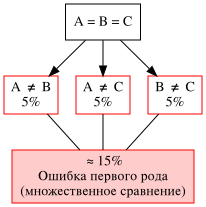

In [ ]:
# Диаграмма с иллюстрацией
from graphviz import Digraph

dot = Digraph(comment='Multiple Comparison Case')
dot.node('abc_equal', 'A = B = C', shape='box', style='filled', fillcolor='white')

dot.node('ab_test', 'A ≠ B\n5%', shape='box', color='red')
dot.node('ac_test', 'A ≠ C\n5%', shape='box', color='red')
dot.node('bc_test', 'B ≠ C\n5%', shape='box', color='red')

dot.node('final', '≈15%\nОшибка первого рода\n(множественное сравнение)', shape='box', style='filled', fillcolor='#ffcccc', color='red')

dot.edge('abc_equal', 'ab_test')
dot.edge('abc_equal', 'ac_test')
dot.edge('abc_equal', 'bc_test')
dot.edge('ab_test', 'final', arrowhead='none')
dot.edge('ac_test', 'final', arrowhead='none')
dot.edge('bc_test', 'final', arrowhead='none')
dot

## Отличия множественных сравнених от проверки отдельных гипотез


**Не множественное сравнение** (можно не делать поправку):

Если нужно дать два отдельных ответа, которые не обобщаются в один вывод, и на основе них будут приниматься разные не влияющие друг на друга решения, тогда гипотезы A=B и A=C будут считаться отдельными, поправка не требуется

- Гипотезы независимы логически и статистически, и выводы по одной не влияют на выводы по другой.
- Они не проверяются в рамках одной задачи или одного набора альтернатив, то есть нет единого "пула" гипотез, из которых мы ищем хотя бы одну "истинную".
- Они не используются для выбора действий из множества (например, оптимизации продукта или сегментации аудитории).


**Множественное сравнение**:

Если нужно дать один ответ на составной вопрос с общим выводом по совокупности тестов, то это множественное сравнение, и без поправки есть риск набрать ложные срабатывания. Тогда для гипотез (A=B или A=C) или (A=B и A=C) нужно применять поправку. Технически поправки для обоих случаев здесь применяются одинаково, хотя поверх тестов логические связки иогут быть выстроены по разному (И/ИЛИ)

- Гипотезы логически связаны и тестируются в рамках одной задачи, например: поиск лучшего варианта из A, B, C, D; выбор фичи, которая даст прирост; сравнение сегментов между собой

Решение принимается по результату **хотя бы одного теста**. В этом случае растёт риск ложноположительных выводов (type I error).

## Способы считать ошибки: FWER и FDR


Стали ли мы чаще ошибаться из-за множественных сравнений? Есть два способа это выяснить ― FWER и FDR.

**FWER**

Family-Wise Error Rate (групповая вероятность ошибки) ― это вероятность совершить хотя бы одну ошибку I-го рода по всем проверкам гипотез (в "семействе" гипотез).

$$FWER = 1-(1-\alpha)^n, \text{где } n- \text{кол-во проверяемых гипотез}$$

Например для 3-х гипотез: $FWER = 1-(1-0.05)^3 = 14.26$

**FDR**

False Discovery Rate (FDR) ― ожидаемая доля ложных отклонений гипотез от кол-ва случаев отклонения гипотез.
Посмотрим на **Confusion matrix** (матрицу ошибок):

<table>
  <tr>
    <th rowspan="2">Наша оценка</th>
    <th colspan="2">Реальность</th>
  </tr>
  <tr>
    <th>Нет эффекта</th>
    <th>Есть эффект</th>
  </tr>
  <tr>
    <td>Нет эффекта</td>
    <td>True Negative (TN) = 1−α</td>
    <td><b>Ошибка 2 рода</b><br>False Negative (FN) = β</td>
  </tr>
  <tr>
    <td>Есть эффект</td>
    <td><b>Ошибка 1 рода</b><br>False Positive (FP) = α</td>
    <td>True Positive (TP) = 1−β</td>
  </tr>
</table>

Сначала надо рассчитать FDP (False Discovery Proportion) — долю ложных отклонений гипотез (когда совершили ошибку первого рода). А FDR — это математическое ожидание доли ложных отклонений гипотез (FDP).

Общая формула (принятая нотация):
$$\mathrm{FDR} = \mathbb{E}\left[\frac{V}{R}\right] = \mathbb{E}[\mathrm{FDP}], \text{ где}$$

$V$ - количество ложноположительных (False Positives)

$R$ - общее число отвергнутых нулевых гипотез (все "обнаруженные" значимые)

Эта формула представляет собой обобщение 2-х случаев:

$$\frac{FP}{FP+TP}, FP+TP>0$$

$$0, FP+TP = 0$$

**Разница между FWER и FDR**

Методы контроля ошибки FWER часто приводят к потере мощности тестов. То есть мы меньше отклоняем нулевые гипотезы там, где эффект на самом деле есть. Это значит, что мы начинаем видеть статистическую значимость только у самых сильных изменений.

Методы контроля FDR позволяют повышать мощность эксперимента, поэтому мы реже пропускаем работающие фичи, что очень важно, если мы работаете в продуктовой команде.

Определяя способ корректировки, мы выбираем между тем, чтобы сделать как можно меньше ложных открытий (FP) ― с этим лучше справляются FWER методики контроля, и тем, чтобы пропустить как можно меньше истинных (FN). Для этого лучше подходят FDR методики контроля, они имеют бОльшую мощность. Какой из подходов выбирать — зависит от целей и традиций в исследованиях каждого типа.



## Способы решения проблемы множественных сравнений


Для решения проблемы множественных сравнений существует большое количество методов поправок. Например:

- Бонферрони (Bonferroni)
- Холма-Бонферрони (Holm–Bonferroni)
- Шидака (Šidák)
- Бенджамини-Хохберга (Benjamini-Hochberg)
- Тьюки (Tukey)
- Даннета (Dunnett)
- Шеффе (Scheffé)

### Бонферрони

Поправка Бонферрони — простая и интуитивно понятная, используется для корректировки FWER. Подсчитывается скорректированный $\alpha$:

$$\alpha' = \frac{\alpha}{n}, \text{ где}$$

$n$ - кол-во проверяемых гипотез

Поправка Бонферрони возвращает альфа в заданные границы, но приходится жертвовать большой потерей мощности. Можно скорректировать это увеличением размера выборки.

Реализация поправки Бонферрони в коде:
```python
a_bonf = alpha / 3 #проверяем 3 гипотезы
alpha_ttest_abc_bonf = np.where(np.array(p_values_abc_alpha) < a_bonf)[0].shape[0] / n_tests
```

Также существуют готовые реализации, например из библиотеки statsmodels (но код может отрабатывать дольше):
```python
multipletests(p_values_abc_alpha[i], alpha = 0.05, method = 'bonferroni')
```

> В целом эта поправка не самая лучшая, ее стоит воспринимать как baseline.

### Холма-Бонферрони

Поправка Холма-Бонферрони — улучшенный вариант поправки Бонферрони, имеющий больше мощности.

Метод работает следующим образом:.

1. Сортировка от меньшего к большему p-value для каждой проверяемой гипотезы.
2. Скорректированный $\alpha$ считается так:

$$\alpha_i = \frac{\alpha}{n-i+1}, i = 1, 2, ..., n, \text{ где}$$

$n$ ― количество гипотез

$i$ ― номер гипотезы

По сути, для первой гипотезы применяется поправка Бонферрони. Для второй гипотезы пороговое значение $\alpha_i$ становится выше (поскольку уменьшается знаменатель), а значит уже менее агрессивным. Для последней гипотезы, где самое высокое p-value, пороговое значение $\alpha_i$ становится равно изначальному значению $\alpha$.

3. Проверка каждой гипотезы, если p-value меньше скорректированного $\alpha_i$, то нулевая гипотеза отклоняется. Если выше или равно $\alpha_i$, то начиная с этой гипотезы и далее — нулевая гипотеза принимается.

Реализация поправки Холма-Бонферрони в коде с помощью библиотеки statsmodels:
```python
multipletests(p_values_abc_alpha[i], alpha = 0.05, method = 'holm')
```

Метод Холма-Бонферрони также нормально восстанавливает альфа. Мощность при этом страдает, но уже в меньшей степени, чем при классическом методе Бонферрони.

### Шидака

Метод Шидака очень прост в реализации и похож на метод Бонферрони, поправка менее строгая, чем Бонферрони, но лишь незначительно. Метод основан на корректировке FWER.

Скорректированный $\alpha$ считается так:

$$\alpha' = 1-(1-\alpha)^\frac{1}{n}, \text{ где}$$

$n$ - кол-во проверяемых гипотез

Реализация метода Шидака в коде с помощью библиотеки statsmodels:
```python
multipletests(p_values_abc_alpha[i], alpha = 0.05, method = 'sidak')
```

Метод Шидака возвращает альфа на нужные значения, но мощность штрафуется достаточно сильно ― на уровне поправки Бонферрони.


### Бенджамини-Хохберга

В отличие от предыдущих трех поправок, поправка Бенджамини-Хохберга позволяет контролировать FDR, который смотрит на пропорции ошибок, а не на сам факт их наличия.
Он не говорит: "была ли ошибка", а говорит: "если были, то сколько среди всех открытий"

Реализация похожа на метод Холма-Бонферрони:

1. Сортировка от меньшего к большему p-value для каждой проверяемой гипотезы.

2. Скорректированный $\alpha$ считается следующим образом:

$$\alpha_i = \frac{\alpha*i}{n}, i = 1, 2, ..., n, \text{ где}$$

$n$ ― количество гипотез

$i$ ― номер гипотезы

3. Проверка каждой гипотезы, если p-value меньше скорректированного $\alpha_i$, то нулевая гипотеза отклоняется, если выше или равно $\alpha_i$, то начиная с этой гипотезы и далее — нулевая гипотеза принимается.

Реализация поправки Бенджамини-Хохберга в коде:
```python
multipletests(test_pval, alpha = 0.05, method = 'fdr_bh')
```

Поправка Бенджамини-Хохберга возвращает альфа на сравнимые с нужными значения. Мощность при этом всё еще штрафуется, но меньше, чем среди других методик (примерно в два раза меньше, чем при поправке Бонферрони).

**Какой способ выбрать?**

Методы контроля FDR (например, Бенжамина-Хохберга) показывают лучшее сохранение мощности. Если вам критично не упустить рабочую фичу, выбирайте их.

В целом, методы достаточно взаимозаменяемы. Они обеспечивают коррекцию до нужного уровня статистической значимости и достаточно легкие в расчетах.


# Практика на симуляции

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from scipy.stats import ttest_ind
from joblib import Parallel, delayed
from tqdm.auto import tqdm
from statsmodels.stats.power import tt_ind_solve_power
from statsmodels.stats.multitest import multipletests
import seaborn as sns

from clickhouse_driver import Client

## AB -тест на проверку одной гипотезы

Просчитаем дизайн эксперимента, сколько нужно в каждой группе для двусторонней проверки гипотез с помощью t-test'а при MDE в 1%, если у нас распределение со средним 10, и стандартным отклонением 2. Для alpha и beta равным 0.05 и 0.2 соответсвенно

Будем использовать его как baseline для сравнения

In [ ]:
mean, std = 10, 2
alpha = 0.05
power = 0.8
beta = 0.2
lift = 0.01
effect_size = mean * lift / std
n_tests = 10000

# функция для генерации 1 выборки и проверки гпитезы о разнице средних с помощью t-теста
def run_ab_test(i, test_mean, test_std):
    values_A = np.random.normal(loc=control_mean, scale=control_std, size=sample_size)
    values_B = np.random.normal(loc=test_mean, scale=test_std, size=sample_size)
    t_stat_ab, p_value_ab = ttest_ind(values_A, values_B, alternative='two-sided')
    return p_value_ab

control_mean, control_std = mean, std
test_mean, test_std = mean * (1 + lift), std
sample_size = round(tt_ind_solve_power(effect_size=effect_size, alpha=alpha, power=power, nobs1=None, alternative = 'two-sided'))#*2

print(f'Effect size = {effect_size:.2f}, \t\tАбсолютный размер эффекта = {mean*lift:.2f}, \tМинимальный размер выборки = {sample_size}')

print(f'\033[1mПроверяем, как выдерживается альфа при остутствии эффекта\033[0m')
p_values_aa_alpha = []
results = Parallel(n_jobs=-1)(delayed(run_ab_test)(i=i, test_mean = control_mean, test_std = control_std) for i in tqdm(range(n_tests)))
for result in results:
    p_values_aa_alpha.append(result)
alpha_ttest_aa = np.where(np.array(p_values_aa_alpha) < alpha)[0].shape[0] / n_tests
print('Alpha для AA =', alpha_ttest_aa, '\n')

print(f'\033[1mПроверяем, как выдерживается power при наличии эффекта\033[0m')
p_values_ab_alpha = []
results = Parallel(n_jobs=-1)(delayed(run_ab_test)(i=i, test_mean = test_mean, test_std = test_std) for i in tqdm(range(n_tests)))
for result in results:
    p_values_ab_alpha.append(result)
power_ttest_ab = np.where(np.array(p_values_ab_alpha) < alpha)[0].shape[0] / n_tests
print('Power для AB =', power_ttest_ab)

Effect size = 0.05, 		Абсолютный размер эффекта = 0.10, 	Минимальный размер выборки = 6280
Проверяем, как выдерживается альфа при остутствии эффекта


  0%|          | 0/10000 [00:00<?, ?it/s]

Alpha для AA = 0.0477 

Проверяем, как выдерживается power при наличии эффекта


  0%|          | 0/10000 [00:00<?, ?it/s]

Power для AB = 0.7994


С помощью симуляции можно убедиться в том, что alpha сохраняется в том уровне, который мы заранее определили. То же самое касается и мощности, при кейсе когда MDE равен реальному эффекту

## АВС-тест

Для проверки того, насколько выдерживаются альфа и мощность проведем 2 вида симуляций для ABC:
1. для альфы сгенерируем 3 выборки из одного распределения (без эффекта) и проверим 3 гипотезы: A=B, A=C, D=C. Для расчета p-value кол-во ложных срабатываний разделим на кол-во измерений. Таким образом будем контролировать Family-Wise Error Rate (FWER) — вероятность хотя бы одной ложной отвержённой гипотезы в группе тестов
2. для проверки мощности в 2 выборки B и C добавим эффект и проверим гипотезы A=B и A=C. Для расчета p-value кол-во одновременных срабатываний разделим на кол-во измерений. Это измерение совместной мощности или пер-сравнение мощности.

### Поведение alpha

Будем проверять 3 гипотезы: A=B, A=C, B=C, с априорным знанием о том, что они верны (будем сэмплировать из одного распределения, не закладывая никакого эффекта)

Для того, чтобы посчитать кол-во ложных срабатываний воспользуемся простой суммой случаев ложного срабатывания

Как мы видим, ошибка первого рода действительно выросла до примерно 15%. Это грустно. Будем учиться это исправлять.

In [ ]:
# Функция, когда эффекта нет нигде
def run_abc_test(i):
    values_A = np.random.normal(loc=control_mean, scale=control_std, size=sample_size)
    values_B = np.random.normal(loc=control_mean, scale=control_std, size=sample_size)
    values_C = np.random.normal(loc=control_mean, scale=control_std, size=sample_size)

    t_stat_ab, p_value_ab = ttest_ind(values_A, values_B, alternative='two-sided')
    t_stat_ac, p_value_ac = ttest_ind(values_A, values_C, alternative='two-sided')
    t_stat_bc, p_value_bc = ttest_ind(values_B, values_C, alternative='two-sided')

    return p_value_ab, p_value_ac, p_value_bc

In [ ]:
mean, std, mde, lift, alpha, beta = 10, 2, 0.01, 0.01, 0.05, 0.2
control_mean, control_std = mean, std
test_mean, test_std = mean * (1 + lift), std
sample_size = round(tt_ind_solve_power(effect_size=effect_size, alpha=alpha, power=power, nobs1=None, alternative = 'two-sided'))#*2

n_tests = 10000

p_values_abc_alpha = []

p_values_abc_alpha = Parallel(n_jobs=-1)(delayed(run_abc_test)(i) for i in tqdm(range(n_tests)))
p_values_abc_alpha = np.array(p_values_abc_alpha)

# Расчет, эквивалентный (np.where(np.array(p_values_abc_alpha) < alpha)[0]).shape[0]
# Возвращает долю всех случаев, когда Н0 отвергается, при отсутствии изменений
alpha_ttest_abc = (p_values_abc_alpha<alpha).sum()/n_tests

print('Alpha t-test two-sided for ABC =', alpha_ttest_abc)
print('Если считать отдельно для каждой гипотезы, то альфа выдерживается')
print('Alpha t-test two-sided for AB = ', len(p_values_abc_alpha[:, 0][p_values_abc_alpha[:, 0] < alpha])/n_tests)
print('Alpha t-test two-sided for AC = ', len(p_values_abc_alpha[:, 1][p_values_abc_alpha[:, 1] < alpha])/n_tests)
print('Alpha t-test two-sided for BC = ', len(p_values_abc_alpha[:, 2][p_values_abc_alpha[:, 2] < alpha])/n_tests)

  0%|          | 0/10000 [00:00<?, ?it/s]

Alpha t-test two-sided for ABC = 0.1587
Если считать отдельно для каждой гипотезы, то альфа выдерживается
Alpha t-test two-sided for AB =  0.0518
Alpha t-test two-sided for AC =  0.0548
Alpha t-test two-sided for BC =  0.0521


### Поведение power

Рассмотрим вариант, когда в тесте есть две "прокрашенных" гипотезы. Проверим 2 гипотезы A=B и A=C (заметим, что 2, а не 3, хотя можно проверить и H0: B=C)

Кол-вом истинных срабатываний будем считать пересечение результатов измерений (кол-во измерений, когда все гипотезы прокрасились), а не сумму случаев в каждом измерении (кол-во срабатываний), и не объединение (кол-во измерений, когда хотя бы 1 гипотеза прокрасилась). Для этого воспользуемся `np.logical_and.reduce([A=B, A=C]).sum()/n_tests`

In [ ]:
# Функция для ситуаций, когда в 2-х выборках есть эффект
def run_abc_test(i):
    values_A = np.random.normal(loc=control_mean, scale=control_std, size=sample_size)
    values_B = np.random.normal(loc=test_mean, scale=test_std, size=sample_size)
    values_C = np.random.normal(loc=test_mean, scale=test_std, size=sample_size)

    t_stat_ab, p_value_ab = ttest_ind(values_A, values_B, alternative='two-sided')
    t_stat_ac, p_value_ac = ttest_ind(values_A, values_C, alternative='two-sided')
    t_stat_bc, p_value_bc = ttest_ind(values_B, values_C, alternative='two-sided')

    return p_value_ab, p_value_ac, p_value_bc

In [ ]:
p_values_abc_power = Parallel(n_jobs=-1)(delayed(run_abc_test)(i) for i in tqdm(range(n_tests)))
p_values_abc_power = np.array(p_values_abc_power)

# Возвращает кол-во всех случаев, когда Н0 отвергается, при том, что изменения есть
#power_ttest_abc = np.logical_and.reduce([(p_values_abc_power<alpha)[:, 0], (p_values_abc_power<alpha)[:, 1], (p_values_abc_power<alpha)[:, 2]]).sum()/n_tests -> 0.0196
power_ttest_abc = np.logical_and.reduce([(p_values_abc_power<alpha)[:, 0], (p_values_abc_power<alpha)[:, 1]]).sum()/n_tests
print('Power t-test two-sided for ABC =', power_ttest_abc)
print('Если считать отдельно для каждой гипотезы, то мощность выдерживается для AB и AC, а для BC изменений не было')
print('Power t-test two-sided for AB = ', len(p_values_abc_power[:, 0][p_values_abc_power[:, 0] < alpha])/n_tests)
print('Power t-test two-sided for AC = ', len(p_values_abc_power[:, 1][p_values_abc_power[:, 1] < alpha])/n_tests)
print('Power t-test two-sided for BC = ', len(p_values_abc_power[:, 2][p_values_abc_power[:, 2] < alpha])/n_tests)

  0%|          | 0/10000 [00:00<?, ?it/s]

Power t-test two-sided for ABC = 0.698
Если считать отдельно для каждой гипотезы, то мощность выдерживается для AB и AC, а для BC изменений не было
Power t-test two-sided for AB =  0.8105
Power t-test two-sided for AC =  0.8046
Power t-test two-sided for BC =  0.0479


В общем, как видим, способы контроля за мощностью и точностью зависит от того, как мы формулируем гипотезу и какую логику агрегации измерений задаем поверх тестов, осмысленную на бизнесовом уровне.

В данной практике договоримся о следующем:

**Истинным срабатыванием TP мы считаем измерения, когда все гипотезы семейства H1 принимаются (при условии, что H1 верна)**

`np.logical_and` в расчете p-value возвращает кол-во измерений (комбинаций результатов тестов всех гипотез), в которых все p-value < alpha. При этом, при сравнении 3-х и более значений нужно использовать `np.logical_and.reduce()`

**Ложным срабатыванием FP мы считаем случаи, когда хотя бы 1 гипотеза из семейства H1 принимается (при условии, что верна H0)**

`np.sum()` возвращает кол-во p-value < alpha.

При варианте с двумя прокрашенными гипотезами у нас рост кумуллятивной ошибки второго рода (когда дожен задетектить оба эффекта, иначе выдается ошибка) работает по той же логике, что и рост FWER альфа.

**Бороться с этим можно тем, что придется в тесты со множественными проверками гипотез закладывать большие размеры выборок.**

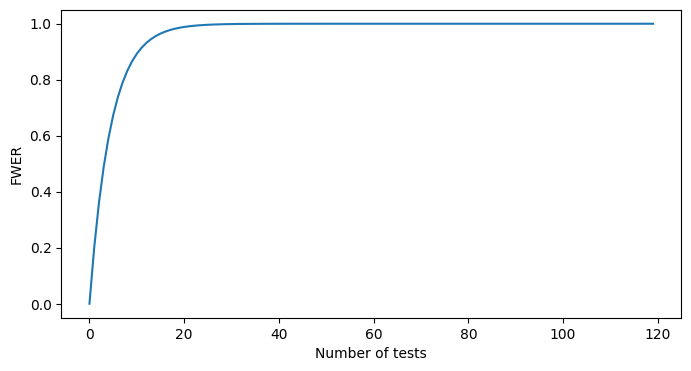

In [ ]:
# график роста FWER
alpha = 0.05
beta = 0.2
x = np.arange(120)
y = 1 - ((1 - beta) ** x)
plt.figure(figsize = (8, 4))
plt.ylabel('FWER')
plt.xlabel('Number of tests')
plt.plot(x, y);

Это график роста групповой ошибки первого рода (alpha), с ростом кол-ва проверяемых гипотез. В один из моментов, у нас ~100% шанса можно обнаружить значимый эффект

## Способы избавиться от роста ошибки первого рода

### Бонферрони

Можно очень легко восспользоваться формулой, а можно готовой реализацией, например из библиотеки statsmodels:
https://www.statsmodels.org/dev/generated/statsmodels.stats.multitest.multipletests.html

С помощью готовой библиотеки statsmodels алгоритм возможно более трудозатратен. Но возвращает те же значения, что и самописная реализация.

In [ ]:
a_bonf = alpha / 3

print(f'Alpha до поправки = {(p_values_abc_alpha<alpha).sum()/n_tests:.3f}, \t\t\t\t\tpower до поправки = {np.logical_and.reduce([(p_values_abc_power<alpha)[:, 0], (p_values_abc_power<alpha)[:, 1]]).sum()/n_tests:.3f}')
print(f'Alpha после поправки Бонферонни (по формуле) = {(p_values_abc_alpha<a_bonf).sum()/n_tests:.3f}, \t\tpower после поправки = {np.logical_and.reduce([(p_values_abc_power<a_bonf)[:, 0], (p_values_abc_power<a_bonf)[:, 1]]).sum()/n_tests:.3f}')

# Создаем массив из 0 размера p-value (10000, 3)
hyps = np.zeros((p_values_abc_alpha.shape[0], p_values_abc_alpha.shape[1]))
for i in range(len(p_values_abc_alpha)):
    hyps[i] = multipletests(p_values_abc_alpha[i], alpha = 0.05, method = 'bonferroni')[0] # первое возвращаемое значение - reject
print(f'Alpha после поправки Бонферонни (функция) = {(hyps==1).sum()/n_tests:.3f}')

Alpha до поправки = 0.159, 					power до поправки = 0.698
Alpha после поправки Бонферонни (по формуле) = 0.054, 		power после поправки = 0.513
Alpha после поправки Бонферонни (функция) = 0.054


Бонферони возвращает альфа в заданные границы, но за это приходится жертвовать большой потерей мощности. Посмотрим как работают другие методики с мощностью и альфа.

### Холма-Бонферрони

In [ ]:
sorted_p_vals_abc = np.sort(p_values_abc_alpha) # Делаем сортировку p-value значения гипотез
rank = range(1, p_values_abc_alpha.shape[1] + 1) #range(1, 3 + 1)
alphas_hb = [(alpha /(p_values_abc_alpha.shape[1] - r + 1)) for r in rank] # скорректированные alpha [0.016666666666666666, 0.025, 0.05]

print(f'Alpha до поправки = {(p_values_abc_alpha<alpha).sum()/n_tests:.3f}, \t\t\t\t\t\tpower до поправки = {np.logical_and.reduce([(p_values_abc_power<alpha)[:, 0], (p_values_abc_power<alpha)[:, 1]]).sum()/n_tests:.3f}')
print(f'Alpha после поправки Холма-Бонферонни (по формуле) = {((sorted_p_vals_abc[:,0]<alphas_hb[0]).sum()+(sorted_p_vals_abc[:,1]<alphas_hb[1]).sum()+(sorted_p_vals_abc[:,2]<alphas_hb[2]).sum())/n_tests:.3f}, '+\
      f'\t\tpower после поправки = {np.logical_and.reduce([p_values_abc_power[:,0]<alphas_hb[0], p_values_abc_power[:,1]<alphas_hb[1]]).sum() / n_tests:.3f}')
'''
Подумать вот над чем (и возможно исправить):
выдерживание мощности мы проверяем только для 2-х первых гипотез, соответственно alphas_hb = [(alpha /(2 - r + 1)) for r in range(1,3)] = [0.025, 0.05]
затем из p_values_abc_power оставляем только первые 2 столбца от 3-х, сотрируем и далее считаем мощность так:
np.logical_and.reduce([np.sort(p_values_abc_power)[:,0]<alphas_hb[0], np.sort(p_values_abc_power)[:,1]<alphas_hb[1]]).sum() / n_tests
'''

# Воспользуемся библиотечной функций и посчитаем альфа
hyps = np.zeros((sorted_p_vals_abc.shape[0], sorted_p_vals_abc.shape[1]))
for i in range(len(p_values_abc_alpha)):
    hyps[i] = multipletests(p_values_abc_alpha[i], alpha = 0.05, method = 'holm')[0] # долго отрабатывает(
print(f'Alpha после поправки Холма-Бонферонни (функция) = {(hyps==1).sum()/n_tests:.3f}')

Alpha до поправки = 0.159, 						power до поправки = 0.698
Alpha после поправки Холма-Бонферонни (по формуле) = 0.059, 		power после поправки = 0.544
Alpha после поправки Холма-Бонферонни (функция) = 0.059


Метод Холма-Бонферрони также нормально восстанавливает альфа. Мощность при этом также страдает, но уже в меньшей степени, чем при классическом методе Бонферрони.

### Шидака

In [ ]:
a_sidak = 1 - (1-alpha)**(1/p_values_abc_alpha.shape[1]) # -> 0.016952427508441503

print(f'Alpha до поправки = {(p_values_abc_alpha<alpha).sum()/n_tests:.3f}, \t\t\t\t\tpower до поправки = {np.logical_and.reduce([(p_values_abc_power<alpha)[:, 0], (p_values_abc_power<alpha)[:, 1]]).sum()/n_tests:.3f}')
print(f'Alpha после поправки Шидака (по формуле) = {(p_values_abc_alpha < a_sidak).sum()/n_tests:.3f}, '+\
      f'\t\tpower после поправки = {np.logical_and.reduce([p_values_abc_power[:,0]<a_sidak, p_values_abc_power[:,1]<a_sidak]).sum() / n_tests:.3f}')

hyps = np.zeros((p_values_abc_alpha.shape[0], p_values_abc_alpha.shape[1]))
for i in range(len(p_values_abc_alpha)):
    hyps[i] = multipletests(p_values_abc_alpha[i], alpha = 0.05, method = 'sidak')[0]
print(f'Alpha после поправки Шидака (функция) = {(hyps==1).sum()/n_tests:.3f}')

Alpha до поправки = 0.159, 					power до поправки = 0.698
Alpha после поправки Шидака (по формуле) = 0.055, 		power после поправки = 0.515
Alpha после поправки Шидака (функция) = 0.055


Метод Шидака возвращает альфа на нужные значения, но мощность штрафуется достаточно сильно, как при Бонферонни

### Бенджамини-Хохберга

In [ ]:
sorted_p_vals_abc = np.sort(p_values_abc_alpha) # Делаем сортировку p-value значения гипотез
rank = range(1, p_values_abc_alpha.shape[1] + 1)
alphas_bh = [(alpha * r) / n for r in rank] # скорректированные alpha [0.016666666666666666, 0.03333333333333333, 0.05000000000000001]

print(f'Alpha до поправки = {(p_values_abc_alpha<alpha).sum()/n_tests:.3f}, \t\t\t\t\t\tpower до поправки = {np.logical_and.reduce([(p_values_abc_power<alpha)[:, 0], (p_values_abc_power<alpha)[:, 1]]).sum()/n_tests:.3f}')
print(f'Alpha после поправки Бенджамини-Хохберга (по формуле) = {((sorted_p_vals_abc[:,0]<alphas_bh[0]).sum()+(sorted_p_vals_abc[:,1]<alphas_bh[1]).sum()+(sorted_p_vals_abc[:,2]<alphas_bh[2]).sum())/n_tests:.3f}, '+\
      f'\t\tpower после поправки = {np.logical_and.reduce([p_values_abc_power[:,0]<alphas_bh[0], p_values_abc_power[:,1]<alphas_bh[1]]).sum() / n_tests:.3f}')

hyps = np.zeros((p_values_abc_alpha.shape[0], p_values_abc_alpha.shape[1]))
for i in range(len(p_values_abc_alpha)):
    hyps[i] = multipletests(p_values_abc_alpha[i], alpha = 0.05, method = 'fdr_bh')[0]
print(f'Alpha после поправки Бенджамини-Хохберга (функция) = {(hyps==1).sum()/n_tests:.3f}')

Alpha до поправки = 0.159, 						power до поправки = 0.698
Alpha после поправки Бенджамини-Хохберга (по формуле) = 0.065, 		power после поправки = 0.565
Alpha после поправки Бенджамини-Хохберга (функция) = 0.068


метод Бенджамини-Хохберга возвращает альфу на нужные значения, мощность штрафуется, но меньше всего среди других методик

# Практика на реальных данных 1

In [ ]:
df = pd.read_csv('psm_data_arpa.csv', index_col = 0)
df

,execution_date,price,year,floor,rooms,square,user_type,revenue
0,2023-05-12,50000000.0,2012,2.0,3,96,1,0
1,2023-05-12,55000000.0,2008,4.0,2,94,1,0
2,2023-05-12,105000000.0,2018,10.0,4,140,1,0
3,2023-05-12,64000000.0,2017,7.0,3,98,1,0
4,2023-05-12,34000000.0,2017,9.0,3,81,1,0
...,...,...,...,...,...,...,...,...
45289,2023-05-12,56000000.0,2021,9.0,3,110,1,0
45290,2023-05-12,76000000.0,2019,3.0,3,110,2,0
45291,2023-05-12,85000000.0,2017,5.0,4,110,2,0
45292,2023-05-12,43000000.0,2011,5.0,3,110,2,0


**Попробуем провести симуляции**
- проведем симуляции на простом АА-тесте. Проверим значения альфа и мощности
- проведем симуляции на ААА-тесте. Проверим значения FWER альфа и мощности
- применим поправки. Посмотрим исправятся ли проблемы

In [ ]:
# Задаем параметры эксперимента
mean, std = df.revenue.mean(), df.revenue.std()
alpha, power, lift = 0.05, 0.8, 0.4
effect_size = mean * lift / std
sample_size = round(tt_ind_solve_power(effect_size=effect_size, alpha=alpha, power=power, nobs1=None, alternative = 'two-sided'))

print(f'Средняя выручка без эффекта = {mean:.2f}, \tАбсолютный размер эффекта = {mean*lift:.2f}, \tСредняя выручка с эффектом = {mean*(1+lift):.2f}')
print(f'Стандартное отклонение = {std:.2f}, \tEffect size = {effect_size:.2f},  \t\t\tМинимальный размер выборки = {sample_size}')

Средняя выручка без эффекта = 109.88, 	Абсолютный размер эффекта = 43.95, 	Средняя выручка с эффектом = 153.83
Стандартное отклонение = 750.46, 	Effect size = 0.06,  			Минимальный размер выборки = 4577


**симуляции на простом АА-тесте**

Генерируем подвыборки по 10000 раз и рандомно задаём группы A и B, где нет эффекта и вычисляем alpha.

В результате симуляции, alpha равен нашей исходной alpha'е при дизайне эксперимента

In [ ]:
def run_ab_test(i, df, sample_size):
    df_n = (df.sample(n = sample_size) # генерим выборку
            .dropna(subset = ['price']).fillna(0).reset_index(drop=True) # удаляем записи с пропущенными ценами, остальные пропуски заполняем 0
            .assign(group = lambda df: np.random.randint(3, size=len(df))) # Генерируем рандомные 3 группы 0, 1, 2
            .assign(group = lambda df: df.group.replace({0: 'A', 1: 'B', 2: 'C'})) # для удобности работы, обозначаем 0, 1, 2 как A, B, C
            )

    values_A = df_n[df_n['group'] == 'A'].revenue
    values_B = df_n[df_n['group'] == 'B'].revenue

    t_stat_ab, p_value_ab = ttest_ind(values_A, values_B, alternative='two-sided')

    return p_value_ab

In [ ]:
n_tests = 10000

p_values_ab = Parallel(n_jobs=-1)(delayed(run_ab_test)(i, df=df, sample_size=sample_size) for i in tqdm(range(n_tests)))
p_values_ab = np.array(p_values_ab)

print(f'Альфа для проверки AB = {(p_values_ab<alpha).sum()/n_tests:.2f}')

  0%|          | 0/10000 [00:00<?, ?it/s]

Альфа для проверки AB = 0.04


**Симуляции на ААА-тесте**

Проверим 3 гипотезы, зная что все выборки взяты из одной популяции и никакого эффекта в них нет

### Без поправок

Как и ожидалось, уровень ошибки I рода увеличился почти в 3 раза

In [ ]:
def run_abc_test(i, df, sample_size):
    df_n = (df.sample(n = sample_size) # генерим выборку
            .dropna(subset = ['price']).fillna(0).reset_index(drop=True) # удаляем записи с пропущенными ценами, остальные пропуски заполняем 0
            .assign(group = lambda df: np.random.randint(3, size=len(df))) # Генерируем рандомные 3 группы 0, 1, 2
            .assign(group = lambda df: df.group.replace({0: 'A', 1: 'B', 2: 'C'})) # для удобности работы, обозначаем 0, 1, 2 как A, B, C
            )

    values_A = df_n[df_n['group'] == 'A'].revenue
    values_B = df_n[df_n['group'] == 'B'].revenue
    values_C = df_n[df_n['group'] == 'C'].revenue

    t_stat_ab, p_value_ab = ttest_ind(values_A, values_B, alternative='two-sided')
    t_stat_aс, p_value_ac = ttest_ind(values_A, values_C, alternative='two-sided')
    t_stat_bс, p_value_bc = ttest_ind(values_B, values_C, alternative='two-sided')

    return p_value_ab, p_value_ac, p_value_bc

In [ ]:
n_tests = 10000

p_values_abс = Parallel(n_jobs=-1)(delayed(run_abc_test)(i, df=df, sample_size=sample_size) for i in tqdm(range(n_tests)))
p_values_abс = np.array(p_values_abс)

print(f'Альфа для проверки ABC без поправки = {(p_values_abс<alpha).sum()/n_tests:.2f}')

  0%|          | 0/10000 [00:00<?, ?it/s]

Альфа для проверки ABC без поправки = 0.14


### Применяем поправки

Для Бонферрони и Шидака и получаем сниженную ошибку первого рода

In [ ]:
a_bonf = alpha / 3
print(f'Альфа при проверки ABC с поправкой Бонферрони = {(p_values_abс<a_bonf).sum()/n_tests:.3f}')

sorted_p_vals_abc = np.sort(p_values_abс) # Делаем сортировку p-value значения гипотез
rank = range(1, p_values_abс.shape[1] + 1) #range(1, 3 + 1)
alphas_hb = [(alpha /(p_values_abс.shape[1] - r + 1)) for r in rank] # скорректированные alpha [0.016666666666666666, 0.025, 0.05]
print(f'Альфа при проверки ABC с поправкой Холма-Бонферрони = {((sorted_p_vals_abc[:,0]<alphas_hb[0]).sum()+(sorted_p_vals_abc[:,1]<alphas_hb[1]).sum()+(sorted_p_vals_abc[:,2]<alphas_hb[2]).sum())/n_tests:.3f}')

a_sidak = 1 - (1-alpha)**(1/3)
print(f'Альфа при проверки ABC с поправкой Шидака = {(p_values_abс<a_sidak).sum()/n_tests:.3f}')

sorted_p_vals_abc = np.sort(p_values_abс) # Делаем сортировку p-value значения гипотез
rank = range(1, p_values_abс.shape[1] + 1) #range(1, 3 + 1)
alphas_bh = [(alpha * r) / p_values_abс.shape[1] for r in rank] # скорректированные alpha [0.016666666666666666, 0.03333333333333333, 0.05000000000000001]
print(f'Альфа при проверки ABC с поправкой Бенджамини-Хохберга = {((sorted_p_vals_abc[:,0]<alphas_bh[0]).sum()+(sorted_p_vals_abc[:,1]<alphas_bh[1]).sum()+(sorted_p_vals_abc[:,2]<alphas_bh[2]).sum())/n_tests:.3f}')

Альфа при проверки ABC с поправкой Бонферрони = 0.037
Альфа при проверки ABC с поправкой Холма-Бонферрони = 0.040
Альфа при проверки ABC с поправкой Шидака = 0.037
Альфа при проверки ABC с поправкой Бенджамини-Хохберга = 0.045


## Рассчет нужного размера выборки

Поставим себе интересную и полезную задачу - определить с помощью симуляции минимальный размер выборки, при котором мы сможем не только свести уровень ошибки I рода в границы установленного $\alpha$, но и сохранить мощность - т.е. не пропустить эффект там, где он есть, т.е. сохранить уровень ошибок II рода в границах 0.2

Определим, что эксперимент планирует проводиться на 3-х группах, одна из которых - контрольная (группа A), а 2 группы тестовые (B и C). Истинным срабатыванием будем считать измерения, когда тест детектирует эффект на заданном уровне значимости для обеих гипотез AB и AC

Результат подтверждает тот факт, что поправки Бонферрони и Шидака наиболее безжалостны к мощности, однако Холма-Бонферрони и Бенджамини-Хохберга справляются лучше

In [ ]:
# Попробуем рассчитать нужный размер выборки под тест с множественными сравнениями
# По умолчанию для корректировки используется метод Бонферрони
# напишем вариант функции, которая может использоваться если данные исторические уже есть

def find_multi_tt_sample_size(hist_data, n_sim, sample_size_start, rel_effect, sample_size_step, power_set, plot = True, method = 'bonferroni'):
    '''
    hist_data - метрика по историческим данным, которую мы используем в тесте
    n_sim - кол-во итерраций симуляции для каждого размера выборки
    sample_size_start - с какого значения выборки начинаем перебор
    rel_effect - какой относительный эффект, MDE хотим проверить
    sample_size_step - шаг приращения размера выборки
    power_set - какой мощности хотим достичь
    plot - Отрисовываем ли график
    method - метод коррекции множественных сравнений
        - `bonferroni` : one-step correction
        - `sidak` : one-step correction
        - `holm-sidak` : step down method using Sidak adjustments
        - `holm` : step-down method using Bonferroni adjustments
        - `simes-hochberg` : step-up method  (independent)
        - `hommel` : closed method based on Simes tests (non-negative)
        - `fdr_bh` : Benjamini/Hochberg  (non-negative)
        - `fdr_by` : Benjamini/Yekutieli (negative)
        - `fdr_tsbh` : two stage fdr correction (non-negative)
        - `fdr_tsbky` : two stage fdr correction (non-negative)

    '''

    sample_size_list = []
    power_value_list = []
    power_value_corrected_list = []

    while True:
        p_value_list = []
        for i in range(n_sim):
            group_a = np.random.choice(hist_data, size = sample_size_start)
            group_b = np.random.choice(hist_data*(1+rel_effect), size = sample_size_start)
            group_c = np.random.choice(hist_data*(1+rel_effect), size = sample_size_start)
            ab_t_stat, ab_p_value = ttest_ind(group_a, group_b)
            ac_t_stat, ac_p_value = ttest_ind(group_a, group_c)
            p_value_list.append((ab_p_value, ac_p_value))

        tp = np.logical_and(np.array(p_value_list)[:, 0] < alpha, np.array(p_value_list)[:, 1] < alpha)

        #скорректируем p-value с помощью поправки
        hypothesys = []
        for i in range(len(p_value_list)):
            hypothesys.append(multipletests(p_value_list[i], alpha = 0.05, method = method)[0])
        tp_corrected =  np.logical_and(np.array(hypothesys)[:,0], np.array(hypothesys)[:,1])

        power_value = tp.mean()
        power_value_corrected = tp_corrected.mean()
        power_value_list.append(power_value)
        power_value_corrected_list.append(power_value_corrected)
        sample_size_list.append(sample_size_start)
        #print(i, sample_size_start, power_value)
        if power_value_corrected > power_set + 0.05:
            break
        else:
            sample_size_start += sample_size_step

    non_corrected_power = power_value_list[np.argmax(np.array(power_value_list) >= 0.8)]
    corrected_power = power_value_corrected_list[np.argmax(np.array(power_value_corrected_list) >= 0.8)]
    non_corrected_sample_size = sample_size_list[np.argmax(np.array(power_value_list) >= 0.8)]
    corrected_sample_size = sample_size_list[np.argmax(np.array(power_value_corrected_list) >= 0.8)]

    if plot: # отрисовываем график набора мощности
        plt.figure(figsize = (16, 8))
        sns.lineplot(x= sample_size_list, y = power_value_list, label = 'Non corrected power')
        sns.lineplot(x= sample_size_list, y = power_value_corrected_list, label = 'Corrected power')
        plt.axhline(y = 0.8, linestyle  = '--', color = 'red')
        plt.axvline(x = non_corrected_sample_size, linestyle  = '--', color = 'red')
        plt.axvline(x = corrected_sample_size, linestyle  = '--', color = 'blue')
        plt.text(x = round(non_corrected_sample_size*0.97), y = 0.3, s = f'Размер выборки без поправки ~ {non_corrected_sample_size}', rotation = 'vertical', color = 'red')
        plt.text(x = round(corrected_sample_size*0.97), y = 0.3, s = f'Размер выборки c поправкой ~ {corrected_sample_size}',  rotation = 'vertical', color = 'blue')

    return_object = {'non_corrected sample_size': non_corrected_sample_size,
                     'corrected sample size': corrected_sample_size,
                    'non corrected power':non_corrected_power,
                    'corrected power':corrected_power }

    return(return_object)

### Бонферрони

{'non_corrected sample_size': 25400,
 'corrected sample size': 29800,
 'non corrected power': np.float64(0.81),
 'corrected power': np.float64(0.8)}

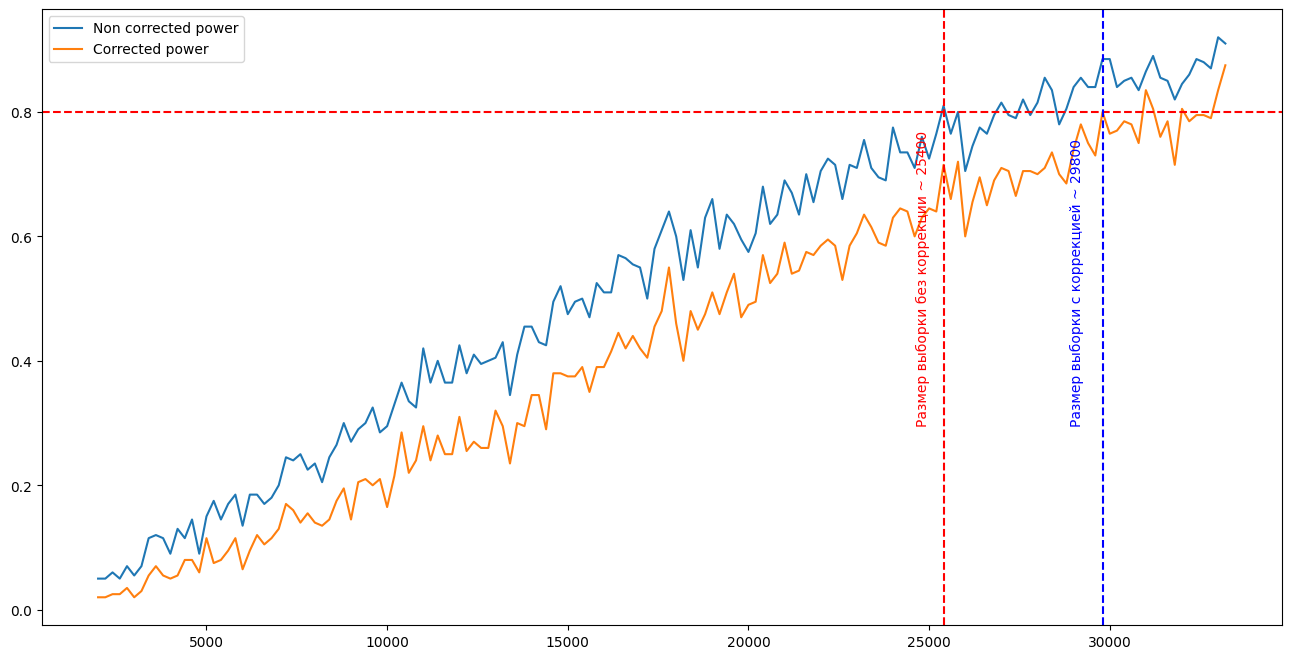

In [ ]:
find_multi_tt_sample_size(hist_data=df.revenue, n_sim=200, sample_size_start=2000, rel_effect=0.2, sample_size_step=200, power_set=0.8, plot = True, method = 'bonferroni')

### Холма-Бонферрони

{'non_corrected sample_size': 26000,
 'corrected sample size': 26000,
 'non corrected power': np.float64(0.83),
 'corrected power': np.float64(0.83)}

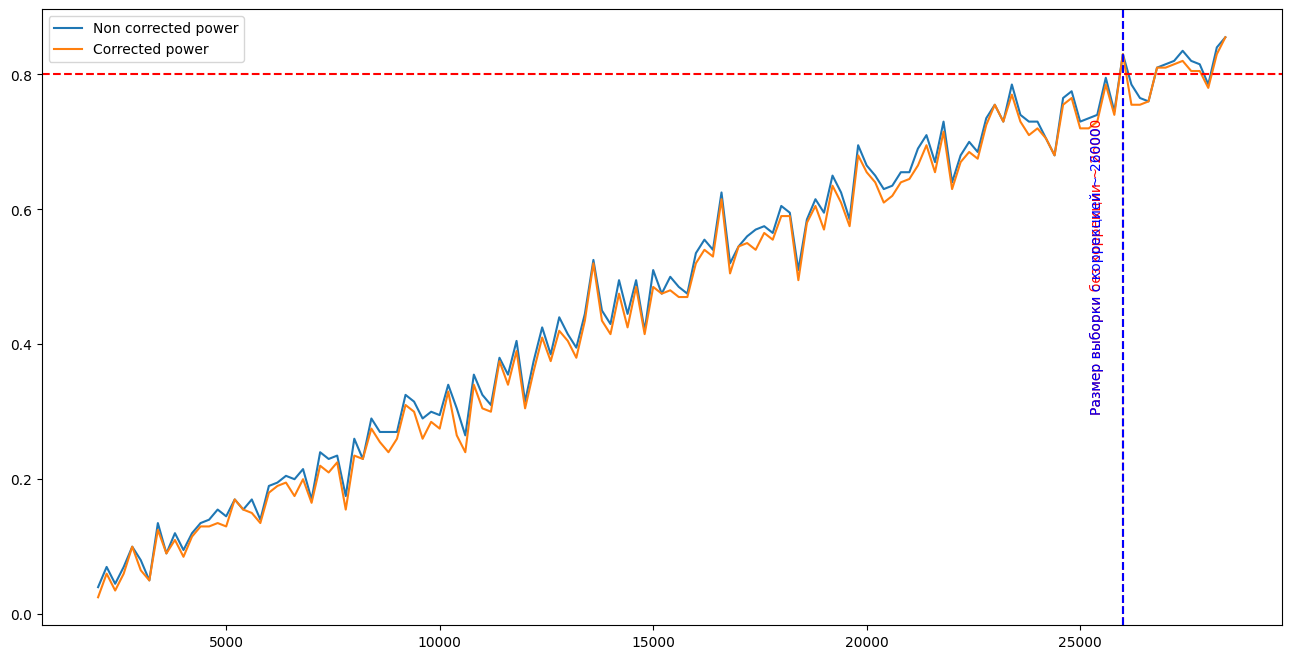

In [ ]:
find_multi_tt_sample_size(hist_data=df.revenue, n_sim=200, sample_size_start=2000, rel_effect=0.2, sample_size_step=200, power_set=0.8, plot = True, method = 'holm')

### Шидака

{'non_corrected sample_size': 25800,
 'corrected sample size': 31400,
 'non corrected power': np.float64(0.82),
 'corrected power': np.float64(0.815)}

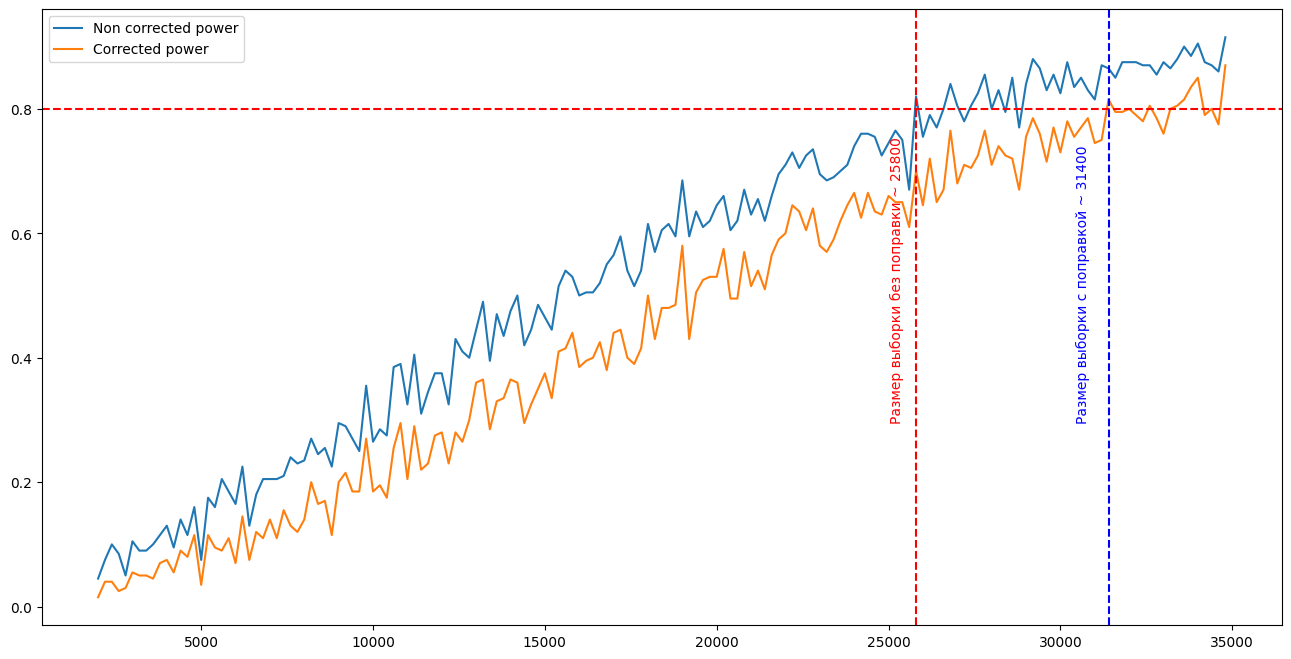

In [ ]:
find_multi_tt_sample_size(hist_data=df.revenue, n_sim=200, sample_size_start=2000, rel_effect=0.2, sample_size_step=200, power_set=0.8, plot = True, method = 'sidak')

### Бенджамини-Хохберга

{'non_corrected sample_size': 25400,
 'corrected sample size': 25400,
 'non corrected power': np.float64(0.81),
 'corrected power': np.float64(0.81)}

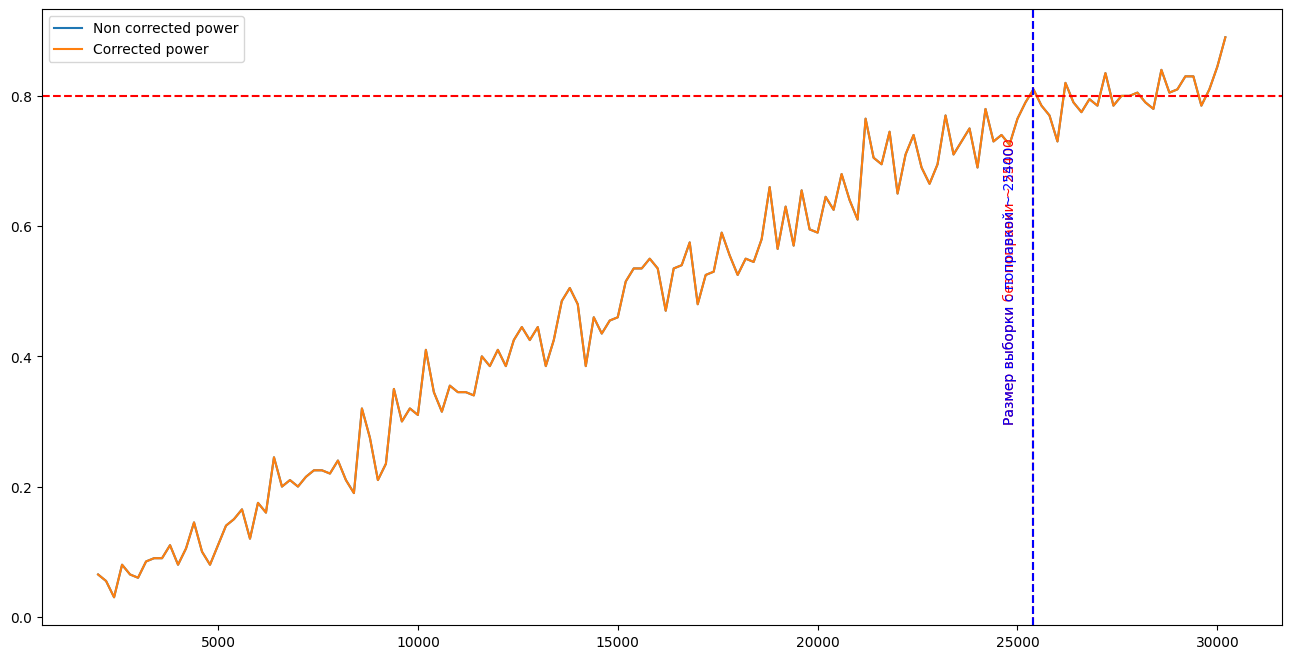

In [ ]:
find_multi_tt_sample_size(hist_data=df.revenue, n_sim=200, sample_size_start=2000, rel_effect=0.2, sample_size_step=200, power_set=0.8, plot = True, method = 'fdr_bh')

# Практика на реальных данных 2

**Задача:** В рамках подготовки к запуску эксперимента  рассчитать необходимый минимальный размер выборок. Цель будущего эксперимента - определить, как изменилась выручка после проведения акции на покупку услуг продвижения VAS (value added services).

**Бизнес-предпосылки:** Пользователи увидят акцию на различных экранах покупки (купить VAS можно в разных местах продукта). Менеджеры хотят проанализировать каждый экран в отдельности и понять, на каком именно экране есть эффект от акции, а кроме того сделать вывод от эффекта акции в целом. Поскольку экранов было несколько, нужно проанализировать ABCD тест и сделать поправку на множественную проверку гипотез. Ожидаемый эффект согласован в размере 20%. Заданные параметры эксперимента: FWER для $\alpha$ = 0.05, мощность = 0.8 (FWER для $\beta$ = 0.2)

**Решение:** Бизнес считает, что цена ошибки II рода достаточна высока, поэтому предпочтение нужно отдать методикам, щадящим мощность. Возьмем поправку Холма-Бонферони и проведем симуляцию, определив в качестве контрольной группы группу А

In [4]:
# Создаем соединение с ClickHouse
client = Client(host='', port=9000, user='', password='', database='')

def get_data(query):
    """
    Вытягивает данные из clickhouse в виде Dataframe
    query - запрос
    """
    result, columns = client.execute(query, with_column_types=True)
    return pd.DataFrame(result, columns=[tuple[0] for tuple in columns])

# данные по каждому пользователю-листеру на каждый день и сумма трат.

query = """
      """

data = get_data(query)

data.fillna(0, inplace = True)
data

,passport_id,money
0,135714633,0.0
1,133483447,0.0
2,138492170,430.0
3,134052529,175.0
4,142968570,215.0
...,...,...
398495,140069146,0.0
398496,123566855,1010.0
398497,133895815,0.0
398498,135858809,3089.0


In [5]:
# метки пользователей сохранены в отдельном файле
user_groups = pd.read_csv('user_groups.csv', index_col=0)
user_groups

,passport_id,group
0,123463044,D
1,123463046,A
2,123463061,C
3,123463062,C
4,123463070,D
...,...,...
398495,143152076,C
398496,143152086,D
398497,143152098,C
398498,143152144,B


In [6]:
df = data.merge(user_groups, on = ['passport_id'])
print('средний ARPU (money) на пользователя по всему датасету = ', round(df['money'].mean(), 2))

средний ARPU (money) на пользователя по всему датасету =  564.38


In [8]:
# Посмотрим на распределение по группам
df.groupby('group', as_index=False).agg(num_customers = ('passport_id','count'), mean = ('money','mean'), median = ('money','median'), max = ('money','max'))

,group,num_customers,mean,median,max
0,A,99285,588.716362,0.0,1107262.0
1,B,99641,527.843047,0.0,347996.0
2,C,100131,554.053060,0.0,528020.0
3,D,99443,587.104361,0.0,1171550.0


Предположим, что нам нужно проверить все 6 гипотез - сравнить все возможные комбинации пар. Посмотрим, как будут выглядеть скорректированные уровни значимости

In [45]:
# Установим уровень значимости альфа = 0.05
p_values = []
for group_0, group_1 in (("A","B"),("A","C"),("A","D"),("B","C"),("B","D"), ("C", "D")):
  t_stat_ab, p_value_ab = ttest_ind(df.query('group==@group_0').money, df.query('group==@group_1').money, alternative='two-sided')
  p_values.append(p_value_ab)

data_hyp = pd.DataFrame({'hypothesis':["AB","AC", "AD", "BC", "BD", "CD"], 'p_values': p_values})

# Поправка Бонферрони
a_bonf = 0.05/6
data_hyp['alpha_bonferroni'] = a_sidak

# Поправка Холма-Бонферрони
rank = range(1, 6 + 1)
alphas_hb = [(0.05 / (6 - r + 1)) for r in rank]
data_hyp = data_hyp.sort_values('p_values').assign(alpha_holm_bonferroni = alphas_hb).sort_values('hypothesis').reset_index(drop=True)

# Поправка Шидака
a_sidak = 1 - (1 - 0.05) ** (1 / 6)
data_hyp['alpha_sidak'] = a_sidak

# Поправка Бенджамини-Хохберга
rank = range(1, 6 + 1)
alphas_bh = [(0.05 * r) / 6 for r in rank]
data_hyp = data_hyp.sort_values('p_values').assign(alpha_benjamini_hochberg = alphas_hb).sort_values('hypothesis').reset_index(drop=True)

data_hyp

,hypothesis,p_values,alpha_bonferroni,alpha_holm_bonferroni,alpha_sidak,alpha_benjamini_hochberg
0,AB,0.008709,0.008512,0.010000,0.008512,0.010000
1,AC,0.146649,0.008512,0.016667,0.008512,0.016667
2,AD,0.954498,0.008512,0.050000,0.008512,0.050000
3,BC,0.106108,0.008512,0.012500,0.008512,0.012500
4,BD,0.007302,0.008512,0.008333,0.008512,0.008333
5,CD,0.147231,0.008512,0.025000,0.008512,0.025000


In [44]:
print(f'Без поправок на уровне значимости 0.05 отвергаем H0: \t{data_hyp[data_hyp.p_values<0.05].hypothesis.to_list()}')
print(f'С поправкой Бонферрони отвергаем H0: \t\t\t{data_hyp[data_hyp.p_values<data_hyp.alpha_bonferroni].hypothesis.to_list()}')
print(f'С поправкой Холма-Бонферрони отвергаем H0: \t\t{data_hyp[data_hyp.p_values<data_hyp.alpha_holm_bonferroni].hypothesis.to_list()}')
print(f'С поправкой Шидака отвергаем H0: \t\t\t{data_hyp[data_hyp.p_values<data_hyp.alpha_sidak].hypothesis.to_list()}')
print(f'С поправкой Бенджамини-Хохберга отвергаем H0: \t\t{data_hyp[data_hyp.p_values<data_hyp.alpha_benjamini_hochberg].hypothesis.to_list()}')

Без поправок на уровне значимости 0.05 отвергаем H0: 	['AB', 'BD']
С поправкой Бонферрони отвергаем H0: 			['BD']
С поправкой Холма-Бонферрони отвергаем H0: 		['AB', 'BD']
С поправкой Шидака отвергаем H0: 			['BD']
С поправкой Бенджамини-Хохберга отвергаем H0: 		['AB', 'BD']


В качестве начального значения размера выборки для детекции эффекта рассчитаем минимальный размер для стандартного t-теста

In [46]:
# Задаем параметры эксперимента
mean, std = df.query('group=="A"').money.mean(), df.query('group=="A"').money.std()
alpha, power, lift = 0.05, 0.8, 0.2
effect_size = mean * lift / std
sample_size = round(tt_ind_solve_power(effect_size=effect_size, alpha=alpha, power=power, nobs1=None, alternative = 'two-sided'))

print(f'Средняя выручка без эффекта = {mean:.2f}, \tАбсолютный размер эффекта = {mean*lift:.2f}, \tСредняя выручка с эффектом = {mean*(1+lift):.2f}')
print(f'Стандартное отклонение = {std:.2f}, \tEffect size = {effect_size:.2f},  \t\t\tМинимальный размер выборки = {sample_size}')

Средняя выручка без эффекта = 588.72, 	Абсолютный размер эффекта = 117.74, 	Средняя выручка с эффектом = 706.46
Стандартное отклонение = 6493.20, 	Effect size = 0.02,  			Минимальный размер выборки = 47741


In [47]:
# Перепишем функцию под эту задачу

def find_multi_tt_sample_size(hist_data, n_sim, sample_size_start, rel_effect, sample_size_step, power_set, plot = True, alpha = 0.05, method = 'bonferroni'):

    sample_size_list = []
    power_value_list = []
    power_value_corrected_list = []

    while True:
        p_value_list = []
        for i in range(n_sim):
            group_a = np.random.choice(hist_data, size = sample_size_start)
            group_b = np.random.choice(hist_data*(1+rel_effect), size = sample_size_start)
            group_c = np.random.choice(hist_data*(1+rel_effect), size = sample_size_start)
            group_d = np.random.choice(hist_data*(1+rel_effect), size = sample_size_start)
            ab_t_stat, ab_p_value = ttest_ind(group_a, group_b)
            ac_t_stat, ac_p_value = ttest_ind(group_a, group_c)
            ad_t_stat, ad_p_value = ttest_ind(group_a, group_d)
            p_value_list.append((ab_p_value, ac_p_value, ad_p_value))

        tp = np.logical_and.reduce([np.array(p_value_list)[:, 0] < alpha, np.array(p_value_list)[:, 1] < alpha, np.array(p_value_list)[:, 2] < alpha])

        #скорректируем p-value через метод
        hypothesys = []
        for i in range(len(p_value_list)):
            hypothesys.append(multipletests(p_value_list[i], alpha = alpha, method = method)[0])
        tp_corrected =  np.logical_and.reduce([np.array(hypothesys)[:,0], np.array(hypothesys)[:,1], np.array(hypothesys)[:,2]])

        power_value = tp.mean()
        power_value_corrected = tp_corrected.mean()
        power_value_list.append(power_value)
        power_value_corrected_list.append(power_value_corrected)
        sample_size_list.append(sample_size_start)
        if power_value_corrected > power_set + 0.05:
            break
        else:
            sample_size_start += sample_size_step

    # рассчитаем итоговые значения размеров выборки
    non_corrected_power = power_value_list[np.argmax(np.array(power_value_list) >= power_set)]
    corrected_power = power_value_corrected_list[np.argmax(np.array(power_value_corrected_list) >= power_set)]
    non_corrected_sample_size = sample_size_list[np.argmax(np.array(power_value_list) >= power_set)]
    corrected_sample_size = sample_size_list[np.argmax(np.array(power_value_corrected_list) >= power_set)]

    #отрисовываем график
    if plot: # отрисовываем график набора мощности
        plt.figure(figsize = (16, 8))
        sns.lineplot(x= sample_size_list, y = power_value_list, label = 'Non corrected power')
        sns.lineplot(x= sample_size_list, y = power_value_corrected_list, label = 'Corrected power')
        plt.axhline(y = 0.8, linestyle  = '--', color = 'red')
        plt.axvline(x = non_corrected_sample_size, linestyle  = '--', color = 'red')
        plt.axvline(x = corrected_sample_size, linestyle  = '--', color = 'blue')

        plt.text(x = round(non_corrected_sample_size * 0.97),
                 y = np.quantile(power_value_list, 0.3),
                 s = f'Размер выборки без коррекции ~ {non_corrected_sample_size}',
                rotation = 'vertical',
                color = 'red')
        plt.text(x = round(corrected_sample_size * 0.97),
                 y = np.quantile(power_value_list, 0.3),
                 s = f'Размер выборки c коррекцией ~ {corrected_sample_size}',
                rotation = 'vertical',
                color = 'blue')

    return_object = {'non_corrected sample_size': non_corrected_sample_size,
                     'corrected sample size': corrected_sample_size,
                    'non corrected power':non_corrected_power,
                    'corrected power':corrected_power }

    return(return_object)

{'non_corrected sample_size': 65000,
 'corrected sample size': 74000,
 'non corrected power': np.float64(0.805),
 'corrected power': np.float64(0.825)}

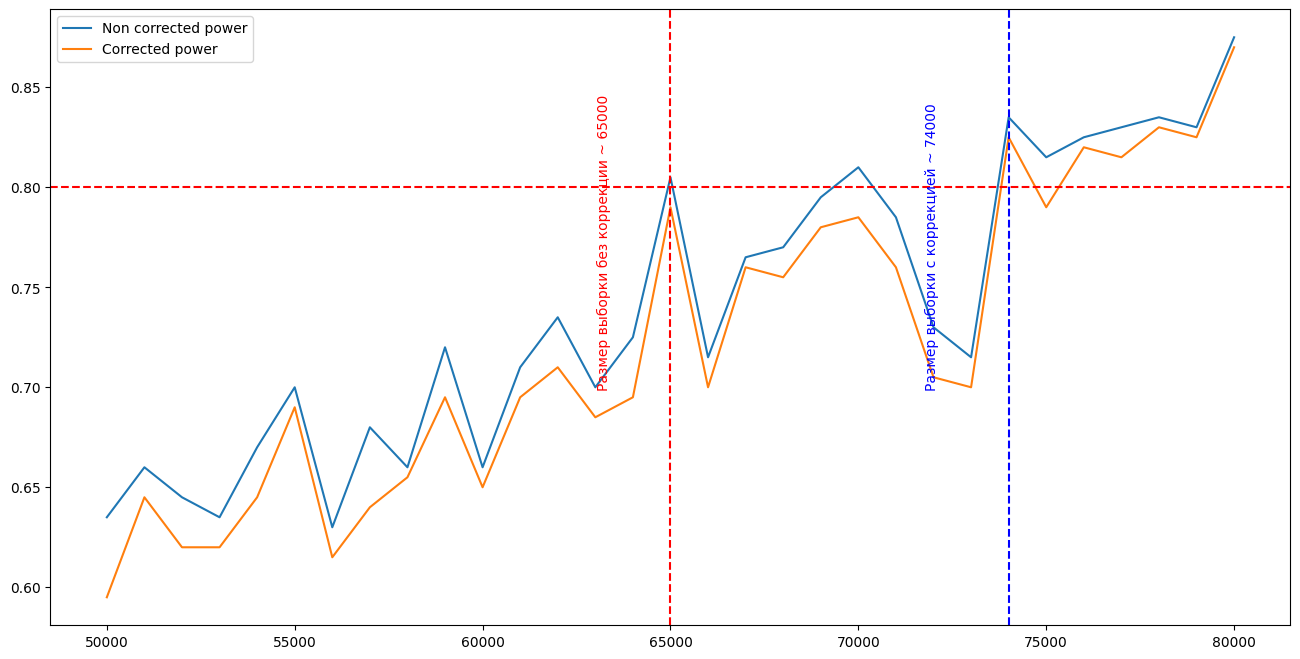

In [48]:
find_multi_tt_sample_size(df.query('group=="A"').money, 200, 50000, 0.2, 1000, 0.8, plot = True, method = 'holm')

# Вывод
- Всегда, когда есть проверка более, чем одной гипотезы на одних данных, есть проблема роста ошибки первого рода.
- Основная причина заключается в вероятности одновременного появления ошибки первого рода по всем гипотезам (FWER).
- Чаще всего сталкиваемся с множественной проверкой гипотез, когда в тесте есть множество различных вариантов (ABC-test), либо множество метрик для принятия решений (например, доля кликов и ARPU).
- Из-за этой ошибки можем принимать варианты, которые на самом деле ничего не дают.
- Бороться с ошибками при множественных сравнениях помогает контроль ошибок FWER и FDR и применение поправок.
- У поправок FWER мощность страдает больше, чем у поправок FDR
Наиболее популярные методы исправления — Холма-Бонферрони (FWER) и Бенжамина-Хогберга (FDR).
- Правильное множественное тестирование позволяет не раскатывать неработающие фичи и не бояться ненастоящих падений.

# Дополнительные материалы

1. [numberanalytics.com](https://www.numberanalytics.com/blog/multiple-testing-correction-methods-theory)
Multiple Testing Correction: Methods & Theory - Number Analytics
15 мая 2025 г. — Error Inflation: When multiple comparisons are conducted, the family-wise error rate (FWER) or false discovery rate (FDR) tends to inflate. This ...

2. Пост на **Medium** предоставляет интуитивное объяснение различий между FWER и FDR, а также их применение в различных сценариях: [Medium](https://medium.com/%40sahn1998/how-to-treat-simultaneous-hypothesis-testing-to-avoid-false-positives-259713a60c6e)
Multiple Hypothesis Testing: FWER & FDR | by Sunghyun Ahn
23 ноября 2024 г. — The False Discovery Rate (FDR) controls the expected proportion of false positives (Type I errors) among all the hypotheses that are rejected.

3. [YouTube](https://www.youtube.com/watch?v=-6zM6mydlfA) 13.2 Introduction to Multiple Testing and Family Wise Error Rate
7 октября 2022 г. — Statistical Learning, featuring Deep Learning, Survival Analysis and Multiple Testing Trevor Hastie, Professor of Statistics and Biomedical ...

4. [Cross Validated](https://stats.stackexchange.com/questions/515854/when-to-care-about-fdr-vs-when-to-care-about-fwer)
When to care about FDR vs when to care about FWER
26 марта 2021 г. — You control FWER when you care about the result of the specific hypotheses tested whereas you control FDR when you care about the number of significant results.

5. Руководство по контролю FDR от **Колумбийского университета** Статья объясняет, как контролировать FDR, включая пошаговые инструкции и обсуждение ограничений метода: [publichealth.columbia.edu](https://www.publichealth.columbia.edu/research/population-health-methods/false-discovery-rat)
False Discovery Rate
The false discovery rate (FDR) is a way to identify as many significant features as possible while incurring a relatively low proportion of false positives.

6. Презентация **Университета Вашингтона** подробно объясняет различные типы ошибок при множественных сравнениях, включая PCER, FWER и FDR, а также методы их контроля: [gs.washington.edu](https://www.gs.washington.edu/academics/courses/akey/56008/lecture/lecture10.pdf)
[PDF] Lecture 10: Multiple Testing
Per comparison error rate (PCER): the expected value of the number of Type I errors over the number of hypotheses,. PCER = E(V)/m. • Per-family error rate ...

7. [Википедия](https://en.wikipedia.org/wiki/False_discovery_rate)
False discovery rate - Wikipedia
In statistics, the false discovery rate (FDR) is a method of conceptualizing the rate of type I errors in null hypothesis testing when conducting multiple ...

8. Руководство от **GrowthBook** описывает различные методы коррекции, включая Bonferroni и Holm, и обсуждает, когда следует использовать FWER или FDR: [docs.growthbook.io](https://docs.growthbook.io/statistics/multiple-corrections)
Multiple Testing Corrections - GrowthBook Docs
The FWER is the probability of at least one test being a false positive. This tends to be much stricter as the number of tests grows.


9. Статья в **PubMed Central** обсуждает философские и практические аспекты множественных сравнений, включая различные методы коррекции и их применение[PMC](https://pmc.ncbi.nlm.nih.gov/articles/PMC4333023/)
Zen and the Art of Multiple Comparisons - PMC
The FWER is defined as the probability of making one or more Type I errors in a family of tests, under the null hypothesis. This implies that in a family of m ...

10. [PMC](https://pmc.ncbi.nlm.nih.gov/articles/PMC5506159/)
A general introduction to adjustment for multiple comparisons - PMC
Therefore, FDR allows the occurrence of Type I errors under a reasonable proportion by taking the total number of rejections into consideration.

11. [stat.berkeley.edu](https://www.stat.berkeley.edu/~hhuang/STAT141/Lecture-FDR.pdf)
[PDF] Type I and Type II errors - UC Berkeley Statistics
False discovery rate (FDR) controls the expected proportion of incorrectly rejected null hypotheses (type I errors) in a list of rejected hypotheses. It is a ...

12. [Computer Science](https://www.cs.unc.edu/~somnath/blogs/multiple-hypothesis-testing.html)
Multiple Hypothesis Testing - [Somnath Basu Roy Chowdhury]
Multiple Hypothesis Testing. Hypothesis testing is a commonnly used method in statistics where we run tests to check whether a null hypothesis H 0 is true ...

13. [statsig.com](https://www.statsig.com/glossary/correction-for-multiple-comparisons)
Correction For Multiple Comparisons - Statsig Glossary
Failing to account for multiple comparisons can lead to inflated false positive rates and erroneous
